# Power Analysis


## Statistical Power

When we do hypothesis testing, a low p-value gives us grounds to reject the Null hypothesis. Recall, a p-value is the probability of seeing data as extreme as (or more extreme than) what you observed, assuming the null hypothesis is true.
But how do we know if our study was actually capable of finding an effect in the first place? That is where the concept of statistical power comes in. Power is the probability that our test will successfully detect a real effect when one truly exists—in other words, the probability of correctly rejecting a false Null hypothesis.

Having clarity on statistical power is important because in real-world experiments, there can be errors when we are testing a hypothesis. For example, we can accidentally get a low p-value (making us reject the Null hypothesis) when actually there is no real effect. This, as we know, is called a **Type I error**. The probability of having a Type I error is denoted by alpha ($\alpha$).On the other hand, there is a possibility that a real effect exists, but our test fails to capture it—this is a **Type II error**. The probability of having a Type II error is denoted by beta ($\beta$).

With power analysis, we want to estimate the probability of successfully **catching an effect** when it is there. Notice this is the exact opposite (the complement) of beta (**missing an effect** when it is there). So, mathematically, $Power = 1 - \beta$.

Power tells you how good your detector is at detecting a real effect.
For example, 80% power means that, assuming the specified effect and other assumptions are correct, the study has an 80% chance of detecting that effect at the chosen significance level.

In [ ]:
library(ggplot2)

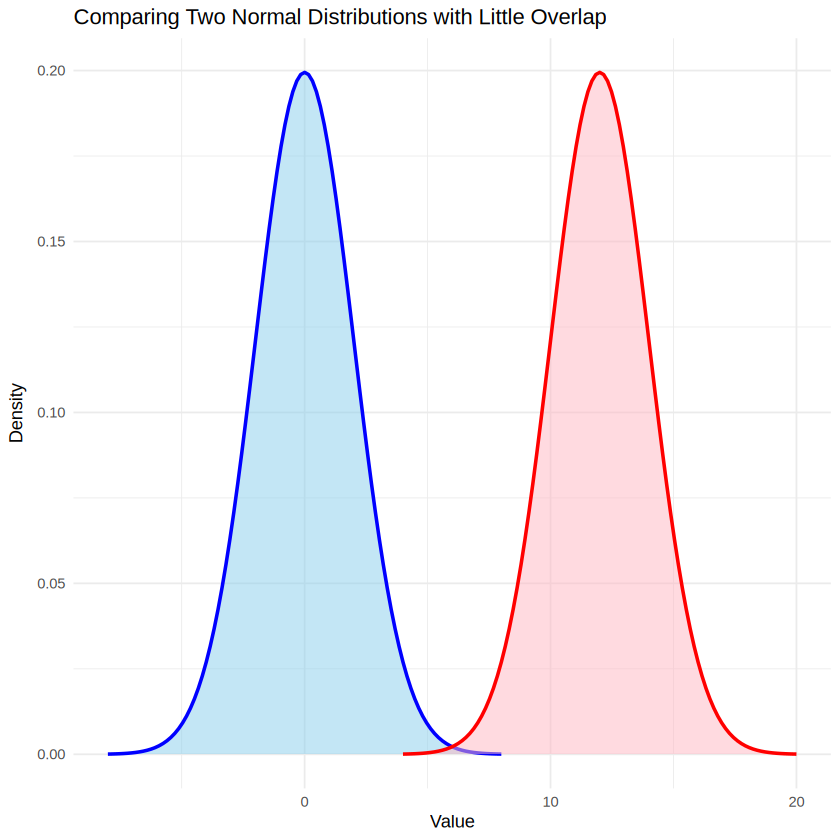

In [ ]:
#| include: false
library(ggplot2)

# Create a blank plot spanning across both distributions with less overlap (from -8 to 20)
ggplot(data.frame(x = c(-8, 20)), aes(x = x)) +
  # First distribution (Mean = 0, sd = 2, restricted from -8 to 8)
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 1, xlim = c(-8, 8)) +

  # Second distribution shifted further right (Mean = 12, sd = 2, restricted from 4 to 20)
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(4, 20)) +
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                color = "red", linewidth = 1, xlim = c(4, 20)) +

  labs(title = "Comparing Two Normal Distributions with Little Overlap",
       x = "Value",
       y = "Density") +
  theme_minimal()

In [8]:
#| include: false
install.packages("patchwork")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



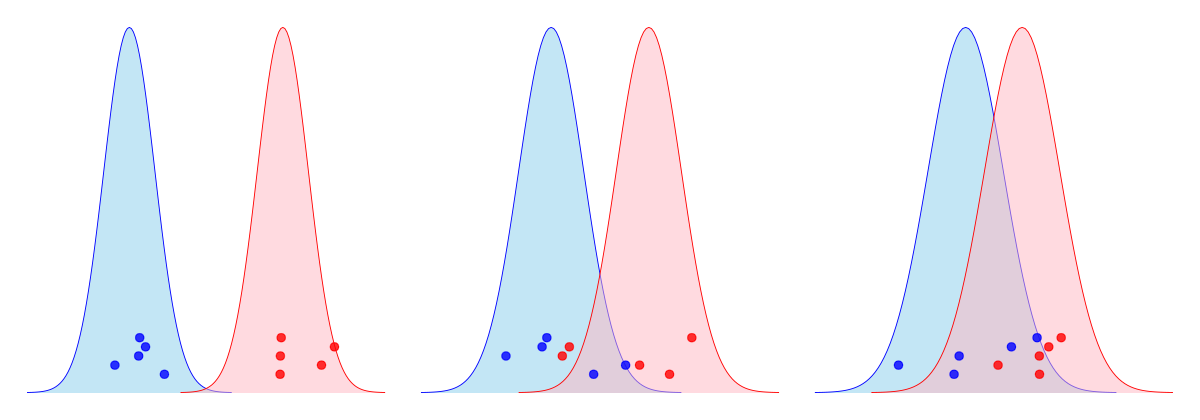

In [30]:
#| fig-cap: "Comparison of normal distributions with little vs. greater overlap. Statistical power decreases from left to right."
#| label: fig-distributions-overlap
#| echo: false
library(ggplot2)
library(patchwork)
options(repr.plot.width = 10, repr.plot.height = 3.5)

# Set seed for reproducibility
set.seed(42)

# Point vertical alignment range (halved y-axis point range relative to graph height)
y_vals_middle <- seq(0.01, 0.03, length.out = 5)

# Helper function to generate random points strictly within a bounded interval
rnorm_bounded <- function(n, mean, sd, min_val, max_val) {
  safe_min <- min_val + 1.0 * sd
  safe_max <- max_val - 1.0 * sd

  pts <- c()
  while(length(pts) < n) {
    candidates <- rnorm(n - length(pts), mean = mean, sd = sd)
    pts <- c(pts, candidates[candidates >= safe_min & candidates <= safe_max])
  }
  return(pts)
}

# --- Left Plot: Little Overlap (Mean 0 vs Mean 12) ---
p1_blue_pts <- data.frame(x = rnorm_bounded(5, mean = 0, sd = 2, min_val = -8, max_val = 8), y = y_vals_middle)
p1_red_pts  <- data.frame(x = rnorm_bounded(5, mean = 12, sd = 2, min_val = 4, max_val = 20), y = y_vals_middle)

p1 <- ggplot(data.frame(x = c(-8, 20)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 0.25, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(4, 20)) +
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                color = "red", linewidth = 0.25, xlim = c(4, 20)) +
  geom_point(data = p1_blue_pts, aes(x = x, y = y), color = "blue", size = 2, alpha = 0.8) +
  geom_point(data = p1_red_pts, aes(x = x, y = y), color = "red", size = 2, alpha = 0.8) +
  theme_void()

# --- Middle Plot: Moderate Overlap (Mean 0 vs Mean 6) ---
p2_blue_pts <- data.frame(x = rnorm_bounded(5, mean = 0, sd = 2, min_val = -8, max_val = 8), y = y_vals_middle)
p2_red_pts  <- data.frame(x = rnorm_bounded(5, mean = 6, sd = 2, min_val = -2, max_val = 14), y = y_vals_middle)

p2 <- ggplot(data.frame(x = c(-8, 14)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 0.25, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 6, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(-2, 14)) +
  stat_function(fun = dnorm, args = list(mean = 6, sd = 2),
                color = "red", linewidth = 0.25, xlim = c(-2, 14)) +
  geom_point(data = p2_blue_pts, aes(x = x, y = y), color = "blue", size = 2, alpha = 0.8) +
  geom_point(data = p2_red_pts, aes(x = x, y = y), color = "red", size = 2, alpha = 0.8) +
  theme_void()

# --- Right Plot: Heavy Overlap (Mean 0 vs Mean 3) ---
# The midpoint between Mean 0 and Mean 3 is 1.5.
p3_blue_x <- c(
  rnorm_bounded(1, mean = 0, sd = 2, min_val = -8, max_val = 1.5),
  rnorm_bounded(4, mean = 0, sd = 2, min_val = -8, max_val = 8)
)
p3_red_x <- c(
  rnorm_bounded(1, mean = 3, sd = 2, min_val = 1.5, max_val = 11),
  rnorm_bounded(4, mean = 3, sd = 2, min_val = -5, max_val = 11)
)

p3_blue_pts <- data.frame(x = p3_blue_x, y = y_vals_middle)
p3_red_pts  <- data.frame(x = p3_red_x, y = y_vals_middle)

p3 <- ggplot(data.frame(x = c(-8, 11)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 0.25, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 3, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(-5, 11)) +
  stat_function(fun = dnorm, args = list(mean = 3, sd = 2),
                color = "red", linewidth = 0.25, xlim = c(-5, 11)) +
  geom_point(data = p3_blue_pts, aes(x = x, y = y), color = "blue", size = 2, alpha = 0.8) +
  geom_point(data = p3_red_pts, aes(x = x, y = y), color = "red", size = 2, alpha = 0.8) +
  theme_void()

# Assemble side-by-side using patchwork
p1 + p2 + p3

As shown in the @fig-distributions-overlap , when there is less overlap between the two distribution then there is a very low probability that the sample data could be from a single distribution. In other words, we have high confidence that the differences we a seeing are real differences. This mean we have high statistical power. On the other hand, when we look a the right-most graph, we can imagine that these points could be from a single distribution since there is high overlap between the two distribution. In this case, theoretically, we can have data points (blue and red) that are exclusively in the non-overlapping regions of the distributions. If that happens then the analysis will indicate that there is significant difference between the two groups. However, the probability of that happening is rather low. So, we can say the in the right-most case, the statistical power is low.

## Factors that affect power

| Factor | Description |
| :--- | :--- |
| **Effect Size** | The magnitude of the difference or relationship between groups. Larger differences between groups are much easier to detect. |
| **Sample Size** | The total number of observations or participants in the study. More data points reduce standard error and provide a sharper estimate. |
| **Significance Level ($\alpha$)** | The threshold set for a statistically significant result (commonly $0.05$). A higher threshold makes it easier to reject the null hypothesis (though it raises false positive risks). |
| **Data Variability ($\sigma$)** | The amount of scatter or noise present within your population data. Tighter distributions make the underlying signal stand out clearly against background noise. |

: Factors affecting satistical power. {#tbl-factors-power .hover tbl-colwidths="[30, 70]"}

## Study design

In [1]:
#| include: false
install.packages("pwr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
#| layout: [[40, 60]]
#| code-fold: true

library(pwr)

# Define Trial Parameters
delta <- 0.5       # Target mean difference in HbA1c (%)
sigma <- 1.2       # Estimated standard deviation (%)
alpha_level <- 0.05 # Significance level (Type I error)
target_power <- 0.80 # Desired statistical power (1 - Type II error)
dropout_rate <- 0.15 # Anticipated patient dropout / attrition rate

# Calculate Cohen's d (Standardized Effect Size)
# d = difference / standard deviation
cohens_d <- delta / sigma
cat("Calculated Cohen's d:", round(cohens_d, 4), "\n")

# Perform Power Analysis for a Two-Sample t-test
power_result <- pwr.t.test(
  d = cohens_d,
  sig.level = alpha_level,
  power = target_power,
  type = "two.sample",
  alternative = "two.sided"
)

print(power_result)

# Extract and calculate sample sizes
n_per_arm <- ceiling(power_result$n)
total_evaluable <- n_per_arm * 2

# Adjust for Attrition
total_recruited <- ceiling(total_evaluable / (1 - dropout_rate))
n_per_arm_recruited <- ceiling(total_recruited / 2)

sample_summary <- data.frame(
  Stage = c("Evaluable", "Evaluable", "Recruitment (15% Attrition)", "Recruitment (15% Attrition)"),
  Parameter = c(
    "Required per arm",
    "Total patients needed",
    "Total patients to recruit",
    "Recruit per arm"
  ),
  Sample_Size = c(
    n_per_arm,
    total_evaluable,
    total_recruited,
    n_per_arm_recruited
  )
)

knitr::kable(sample_summary)

Calculated Cohen's d: 0.4167 

     Two-sample t test power calculation 

              n = 91.38922
              d = 0.4166667
      sig.level = 0.05
          power = 0.8
    alternative = two.sided

NOTE: n is number in *each* group





|Stage                       |Parameter                 | Sample_Size|
|:---------------------------|:-------------------------|-----------:|
|Evaluable                   |Required per arm          |          92|
|Evaluable                   |Total patients needed     |         184|
|Recruitment (15% Attrition) |Total patients to recruit |         217|
|Recruitment (15% Attrition) |Recruit per arm           |         109|

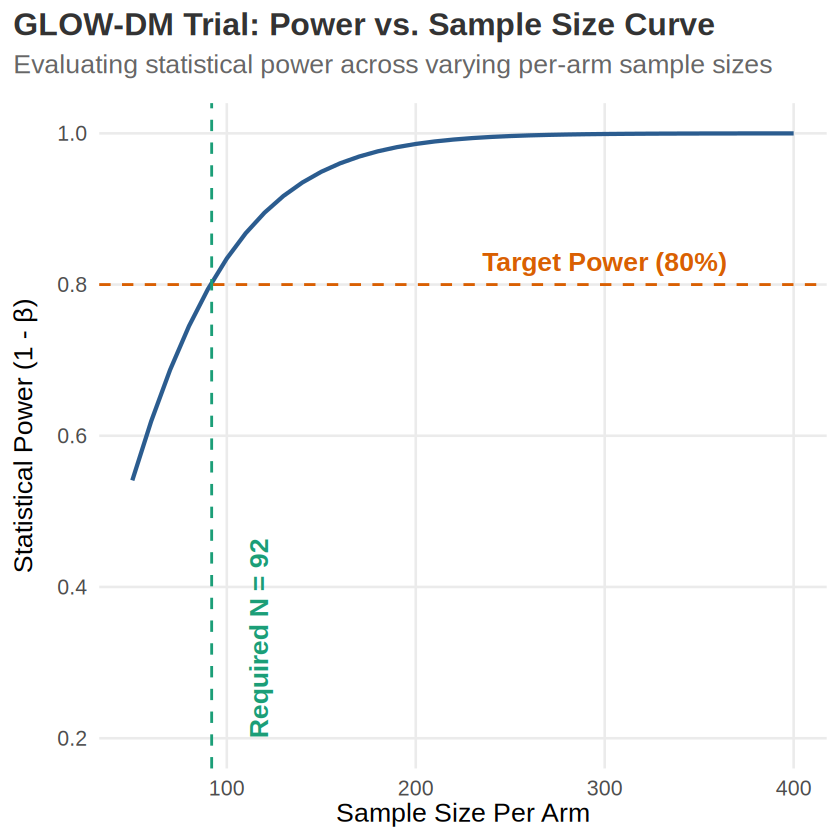

In [7]:
# Generating a Power Curve for Visualization
sample_sizes <- seq(50, 400, by = 10)
calculated_power <- sapply(sample_sizes, function(n) {
  pwr.t.test(d = cohens_d, n = n, sig.level = alpha_level, type = "two.sample")$power
})

# Plotting the curve
library(ggplot2)

# Prepare data for ggplot
plot_data <- data.frame(
  sample_size = sample_sizes,
  power = calculated_power
)

# Create the ggplot visualization
ggplot(plot_data, aes(x = sample_size, y = power)) +
  # Power curve line
  geom_line(color = "#2b5c8f", linewidth = 1.2) +

  # Threshold lines for 80% power and required sample size
  geom_hline(yintercept = target_power, color = "#d95f02", linetype = "dashed", linewidth = 0.8) +
  geom_vline(xintercept = n_per_arm, color = "#1b9e77", linetype = "dashed", linewidth = 0.8) +

  # Annotations to make the plot self-explanatory for students
  annotate("text", x = max(plot_data$sample_size) * 0.75, y = target_power + 0.03,
           label = paste0("Target Power (", target_power * 100, "%)"), color = "#d95f02", fontface = "bold") +
  annotate("text", x = n_per_arm + 25, y = 0.2,
           label = paste0("Required N = ", n_per_arm), color = "#1b9e77", fontface = "bold", angle = 90, hjust=0) +

  # Labels and clean theme
  labs(
    title = "GLOW-DM Trial: Power vs. Sample Size Curve",
    subtitle = "Evaluating statistical power across varying per-arm sample sizes",
    x = "Sample Size Per Arm",
    y = expression("Statistical Power (1 - " * beta * ")")
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", color = "#333333",hjust = 0),
    plot.title.position = "plot",
    plot.subtitle = element_text(color = "#666666", margin = margin(b = 15)),
    panel.grid.minor = element_blank()
  )

## Importance of Power Analysis